# Climate Event Predictor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             mean_squared_error, r2_score, mean_absolute_error)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('climate_events.csv')

### Data Exploration and Visualization

In [3]:
df.head()

,event_id,date,year,month,country,event_type,severity,duration_days,affected_population,deaths,injuries,economic_impact_million_usd,infrastructure_damage_score,response_time_hours,international_aid_million_usd,latitude,longitude,total_casualties,impact_per_capita,aid_percentage
0,EV01539,2020-01-01,2020,1,Japan,Tsunami,1,1,420956,0,2,0.01,4.9,11,0.0,85.4321,138.7206,2,0.02,0.0
1,EV02303,2020-01-01,2020,1,Qatar,Hurricane,1,4,3276,1,10,0.00,3.4,5,0.0,-32.0370,14.0111,11,0.00,0.0
2,EV01796,2020-01-02,2020,1,Canada,Drought,3,6,120382,0,9,0.10,8.9,10,0.0,78.4213,-112.7556,9,0.83,0.0
3,EV00175,2020-01-02,2020,1,Poland,Heatwave,6,16,185527,2,37,1.27,17.8,7,0.0,73.6564,115.0650,39,6.85,0.0
4,EV01115,2020-01-03,2020,1,UAE,Wildfire,4,16,176642,2,27,2.01,18.7,17,0.0,52.6458,101.5023,29,11.38,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   event_id                       3000 non-null   object 
 1   date                           3000 non-null   object 
 2   year                           3000 non-null   int64  
 3   month                          3000 non-null   int64  
 4   country                        3000 non-null   object 
 5   event_type                     3000 non-null   object 
 6   severity                       3000 non-null   int64  
 7   duration_days                  3000 non-null   int64  
 8   affected_population            3000 non-null   int64  
 9   deaths                         3000 non-null   int64  
 10  injuries                       3000 non-null   int64  
 11  economic_impact_million_usd    3000 non-null   float64
 12  infrastructure_damage_score    3000 non-null   f

In [5]:
df.describe()

,year,month,severity,duration_days,affected_population,deaths,injuries,economic_impact_million_usd,infrastructure_damage_score,response_time_hours,international_aid_million_usd,latitude,longitude,total_casualties,impact_per_capita,aid_percentage
count,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2022.401667,6.260333,3.786333,8.783000,8.685505e+05,4.615000,39.228333,1.944367,15.160733,11.107667,0.057020,-0.053334,-0.133522,43.843333,3.613917,0.009267
std,1.653857,3.367146,2.005165,14.714508,3.009690e+06,11.021491,78.812194,15.734990,11.501826,8.255753,3.005868,51.985637,103.941947,85.943626,10.779860,0.427530
min,2020.000000,1.000000,1.000000,0.000000,6.220000e+02,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,-89.756300,-179.982700,0.000000,0.000000,0.000000
25%,2021.000000,3.000000,2.000000,1.000000,5.451775e+04,1.000000,10.000000,0.010000,6.000000,5.000000,0.000000,-44.905350,-89.849575,11.000000,0.080000,0.000000
50%,2022.000000,6.000000,4.000000,2.000000,1.784770e+05,2.000000,18.000000,0.090000,12.400000,9.000000,0.000000,-1.506450,-0.368500,20.000000,0.480000,0.000000
75%,2024.000000,9.000000,5.000000,9.000000,6.082012e+05,3.000000,27.000000,0.530000,21.425000,15.000000,0.000000,46.775275,93.652275,29.000000,2.132500,0.000000
max,2025.000000,12.000000,9.000000,115.000000,5.624832e+07,117.000000,734.000000,718.210000,63.000000,60.000000,164.510000,89.976900,179.964400,738.000000,181.620000,22.900000


In [6]:
df.isnull().sum()

event_id                         0
date                             0
year                             0
month                            0
country                          0
event_type                       0
severity                         0
duration_days                    0
affected_population              0
deaths                           0
injuries                         0
economic_impact_million_usd      0
infrastructure_damage_score      0
response_time_hours              0
international_aid_million_usd    0
latitude                         0
longitude                        0
total_casualties                 0
impact_per_capita                0
aid_percentage                   0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

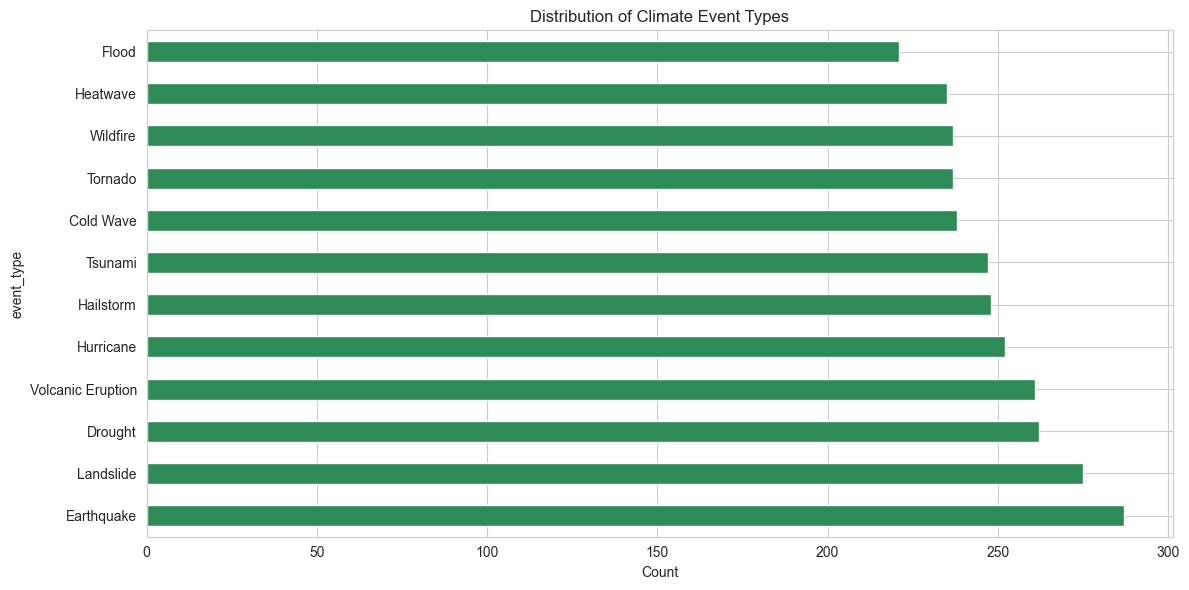

In [8]:
plt.figure(figsize=(12, 6))
df['event_type'].value_counts().plot(kind='barh', color='seagreen')
plt.title('Distribution of Climate Event Types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

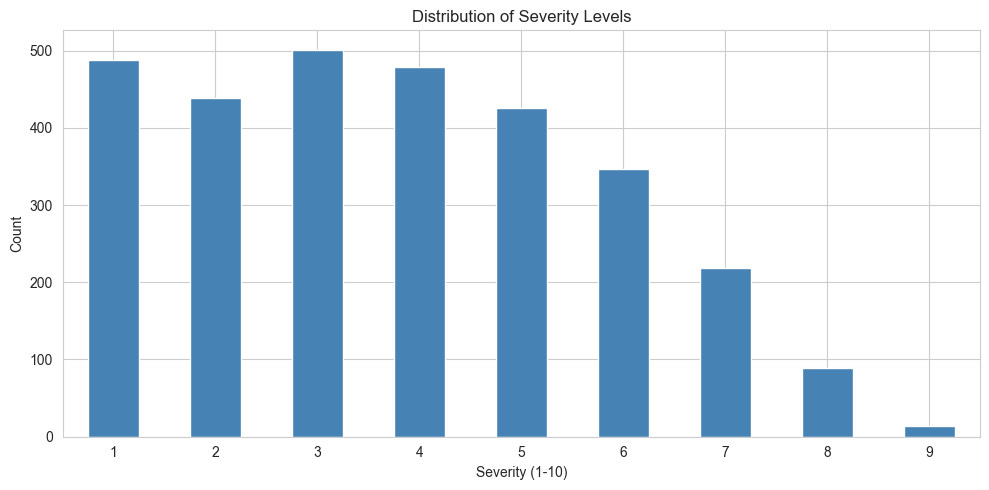

In [9]:
# Distribution of severity (the classification target)
plt.figure(figsize=(10, 5))
df['severity'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Severity Levels')
plt.xlabel('Severity (1-10)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

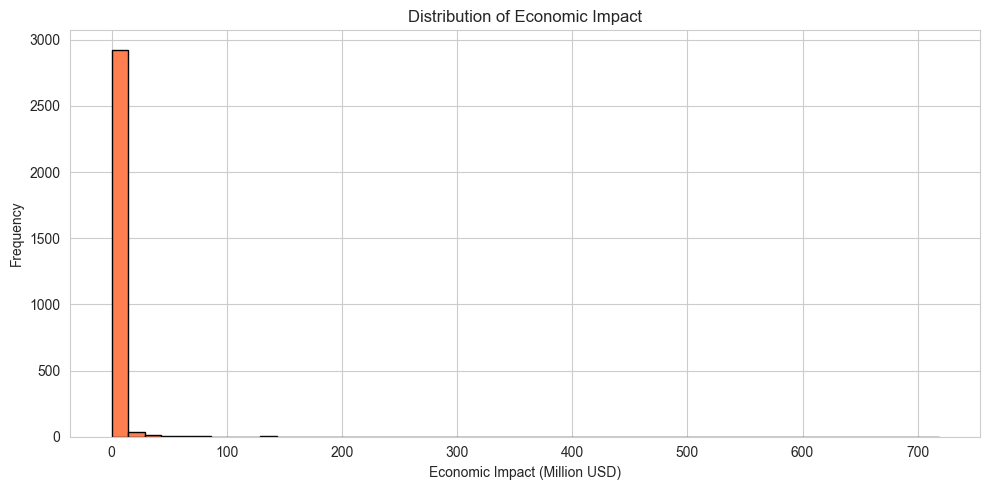

In [10]:
# Distribution of economic impact (the regression target)
plt.figure(figsize=(10, 5))
plt.hist(df['economic_impact_million_usd'], bins=50, color='coral', edgecolor='black')
plt.title('Distribution of Economic Impact')
plt.xlabel('Economic Impact (Million USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Data PreProcessing

In [11]:
df_processed = df.copy()

In [12]:
df_processed['date'] = pd.to_datetime(df_processed['date'])
df_processed['day_of_year'] = df_processed['date'].dt.dayofyear
df_processed['quarter'] = df_processed['date'].dt.quarter

In [13]:
lencode_country = LabelEncoder()
df_processed['country_encoded'] = lencode_country.fit_transform(df_processed['country'])

df_processed = pd.get_dummies(df_processed, columns=['event_type'], prefix='event_type')

bool_cols = [col for col in df_processed.columns if 'event_type_' in col]
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

### Feature Engineering

In [14]:
# 1. Casualty rate
df_processed['casualty_rate'] = (
    df_processed['total_casualties'] / (df_processed['affected_population'] + 1)
)

# 2. Response efficiency (Could help predict severity indirectly as severe events may call for faster responses)
df_processed['response_efficiency'] = (
    df_processed['response_time_hours'] / (df_processed['duration_days'] + 1)
)

# 3. Additional interaction features for better economic prediction
df_processed['severity_x_duration'] = df['severity'] * df['duration_days']
df_processed['total_casualties'] = df['deaths'] + df['injuries']
df_processed['deaths_per_affected'] = df['deaths'] / (df['affected_population'] + 1)
df_processed['damage_per_day'] = df['infrastructure_damage_score'] / (df['duration_days'] + 1)
df_processed['lat_long_interaction'] = df['latitude'] * df['longitude']
df_processed['casualties_x_damage'] = df_processed['total_casualties'] * df['infrastructure_damage_score']
df_processed['population_density_proxy'] = df['affected_population'] / (df['duration_days'] + 1)

In [15]:
percentile_995 = df_processed['economic_impact_million_usd'].quantile(0.995)
df_processed['economic_impact_capped'] = df_processed['economic_impact_million_usd'].clip(upper=percentile_995)
print(f"Max value before capping: ${df_processed['economic_impact_million_usd'].max():.2f}M")

df_processed['economic_impact_capped'] = df_processed['economic_impact_million_usd'].clip(upper=percentile_995)

print(f"Max value after capping: ${df_processed['economic_impact_capped'].max():.2f}M")
print(f"Number of values capped: {(df_processed['economic_impact_million_usd'] > percentile_995).sum()}")

Max value before capping: $718.21M
Max value after capping: $55.33M
Number of values capped: 15


### Preparing Data for Modeling

In [16]:
event_cols = [col for col in df_processed.columns if 'event_type_' in col]

base_features = [
    'year', 'month', 'quarter', 'day_of_year',
    'country_encoded',
    'duration_days', 'affected_population', 'deaths', 'injuries',
    'infrastructure_damage_score', 'response_time_hours',
    'latitude', 'longitude',
    'response_efficiency',
    'casualty_rate',
    'severity_x_duration',
    'total_casualties',
    'deaths_per_affected',
    'damage_per_day',
    'lat_long_interaction',
    'casualties_x_damage',
    'population_density_proxy'
]

feature_cols = base_features + event_cols

y_severity = pd.cut(df_processed['severity'], 
                    bins=[0, 3, 7, 10], 
                    labels=[0, 1, 2]).astype(int)

X_severity = df_processed[feature_cols]

y_economic = np.log1p(df_processed['economic_impact_capped'])

X_economic = df_processed[feature_cols]

### Train and Test Data Split

In [17]:
X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_severity, y_severity, test_size=0.2, random_state=42, stratify=y_severity
)

X_eco_train, X_eco_test, y_eco_train, y_eco_test = train_test_split(
    X_economic, y_economic, test_size=0.2, random_state=42
)

### Feature Scaling

In [18]:
scaler_sev = StandardScaler()
scaler_eco = StandardScaler()

X_sev_train_scaled = scaler_sev.fit_transform(X_sev_train)
X_sev_test_scaled = scaler_sev.transform(X_sev_test)

X_eco_train_scaled = scaler_eco.fit_transform(X_eco_train)
X_eco_test_scaled = scaler_eco.transform(X_eco_test)

### Training the Model (Severity Prediction) - Classification

In [19]:
rf_severity = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

In [20]:
rf_severity.fit(X_sev_train_scaled, y_sev_train)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_sev_pred = rf_severity.predict(X_sev_test_scaled)

In [22]:
print(classification_report(y_sev_test, y_sev_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       285
           1       0.89      0.92      0.90       294
           2       0.50      0.05      0.09        21

    accuracy                           0.90       600
   macro avg       0.77      0.64      0.64       600
weighted avg       0.89      0.90      0.89       600



In [23]:
accuracy = (y_sev_pred == y_sev_test).mean()
print(f"\nOverall Accuracy: {accuracy:.2%}")


Overall Accuracy: 90.33%


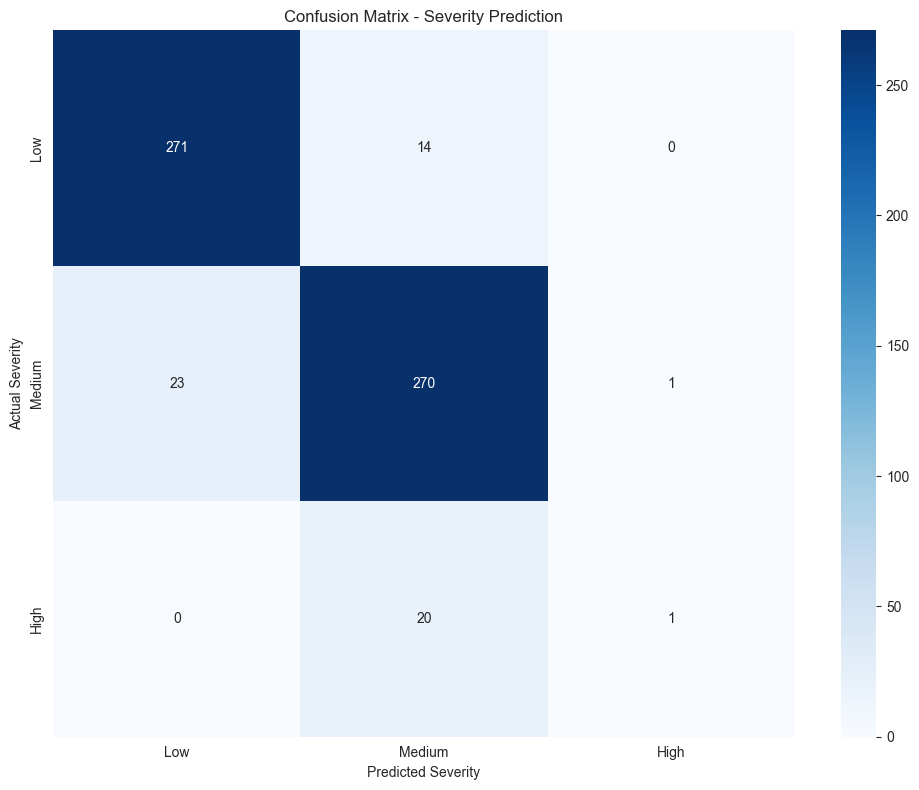

In [24]:
cm_severity = confusion_matrix(y_sev_test, y_sev_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_severity, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix - Severity Prediction')
plt.ylabel('Actual Severity')
plt.xlabel('Predicted Severity')
plt.tight_layout()
plt.show()

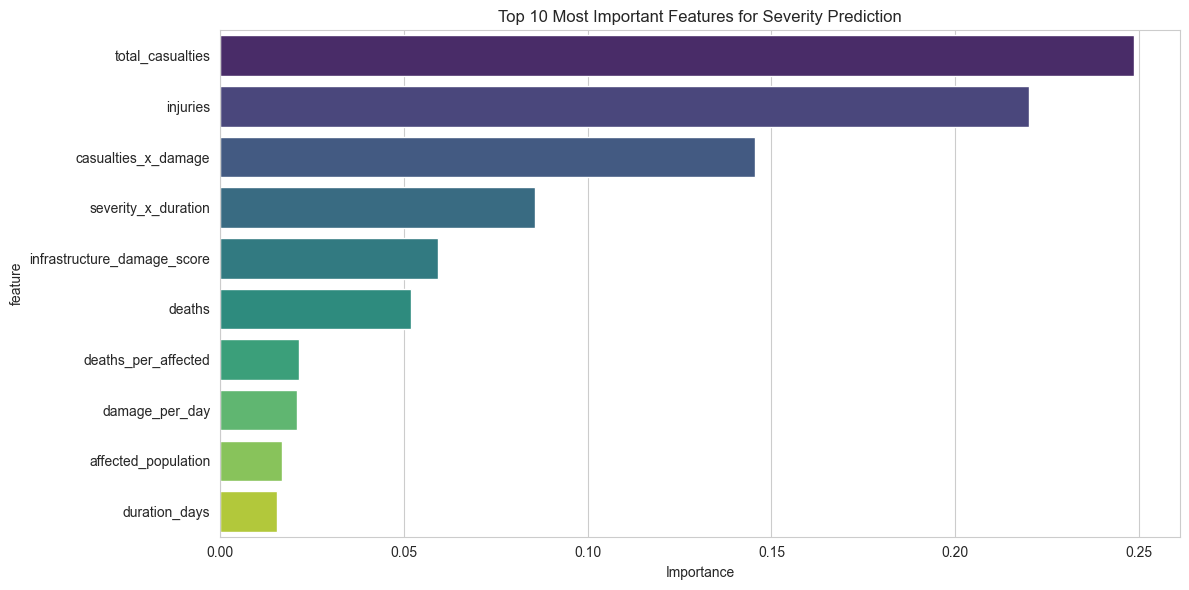


Top 10 Important Features:
                        feature  importance
16             total_casualties    0.248755
8                      injuries    0.219969
20          casualties_x_damage    0.145515
15          severity_x_duration    0.085666
9   infrastructure_damage_score    0.059219
7                        deaths    0.052067
17          deaths_per_affected    0.021342
18               damage_per_day    0.021033
6           affected_population    0.016899
5                 duration_days    0.015405


In [25]:
feature_importance_sev = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_severity.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_sev.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Most Important Features for Severity Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance_sev.head(10))

### Training the Model (Economic Impact Prediction) - Regression

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

rf_economic = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
rf_economic.fit(X_eco_train_scaled, y_eco_train)

y_eco_pred_log = rf_economic.predict(X_eco_test_scaled)
y_eco_pred = rf_economic.predict(X_eco_test_scaled)
mae = mean_absolute_error(y_eco_test, y_eco_pred)
mse = mean_squared_error(y_eco_test, y_eco_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_eco_test, y_eco_pred)

print(f"\nMean Absolute Error (MAE): ${mae:.2f} million")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f} million")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): $0.20 million
Root Mean Squared Error (RMSE): $0.37 million
R² Score: 0.7960


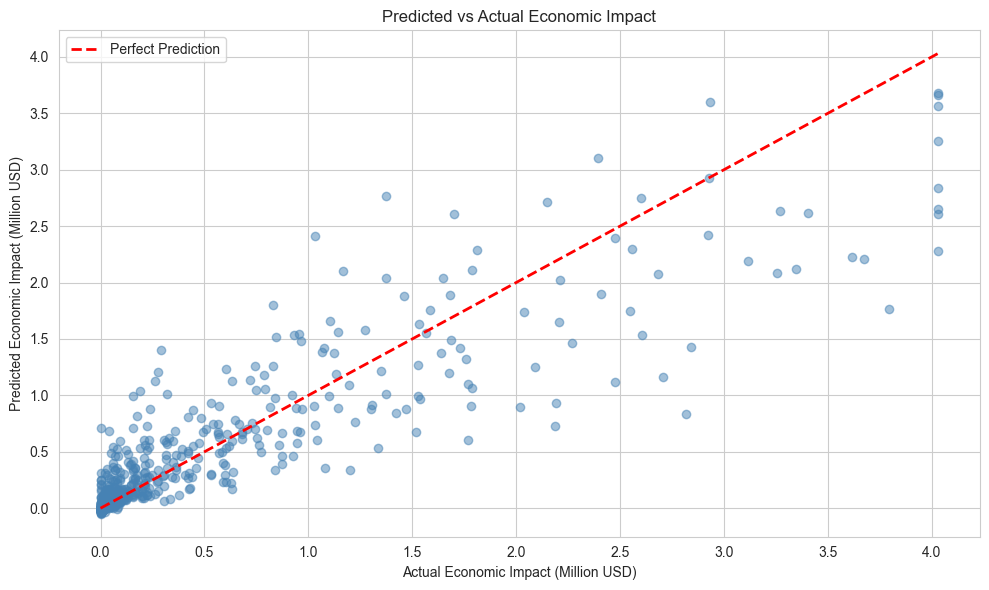

In [27]:
# Predicted vs Actual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_eco_test, y_eco_pred, alpha=0.5, color='steelblue')
plt.plot([y_eco_test.min(), y_eco_test.max()], 
         [y_eco_test.min(), y_eco_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Economic Impact (Million USD)')
plt.ylabel('Predicted Economic Impact (Million USD)')
plt.title('Predicted vs Actual Economic Impact')
plt.legend()
plt.tight_layout()
plt.show()

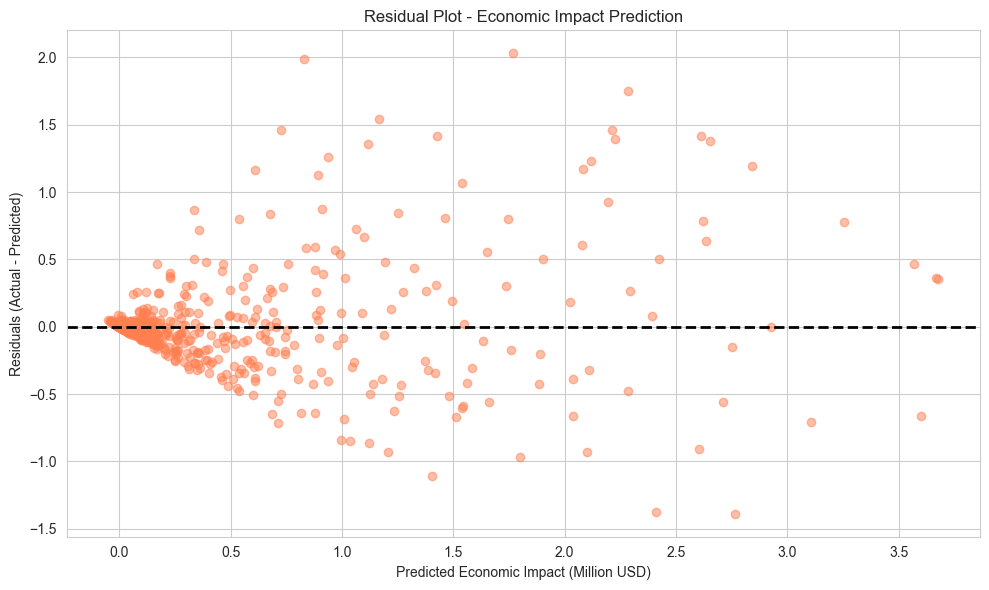

In [28]:
# Residual plot
residuals = y_eco_test - y_eco_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_eco_pred, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Predicted Economic Impact (Million USD)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Economic Impact Prediction')
plt.tight_layout()
plt.show()